In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
logistic_model = joblib.load(
    "../models/logistic_model.pkl"
)

rf_model = joblib.load(
    "../models/random_forest_model.pkl"
)

xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

print("Models loaded successfully!")

Models loaded successfully!


In [3]:
df = pd.read_csv(
    "../data/processed/churn_feature_engineered.csv"
)

df = df.drop("customerID", axis=1, errors="ignore")

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1409, 28)
y_test: (1409,)


In [5]:
X_test_processed = preprocessor.transform(X_test)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed test shape: (1409, 57)


In [6]:
logistic_pred = logistic_model.predict(
    X_test_processed
)

logistic_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [7]:
rf_pred = rf_model.predict(
    X_test_processed
)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [8]:
xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [9]:
def evaluate_model(name, y_true, y_pred, y_prob):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [10]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.798439,0.653061,0.513369,0.574850,0.842533
1,Random Forest,0.760114,0.542453,0.614973,0.576441,0.823261
2,XGBoost,0.794180,0.638158,0.518717,0.572271,0.837893


In [11]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7984,0.6531,0.5134,0.5749,0.8425
1,Random Forest,0.7601,0.5425,0.6150,0.5764,0.8233
2,XGBoost,0.7942,0.6382,0.5187,0.5723,0.8379


In [12]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.798439,0.653061,0.513369,0.574850,0.842533
2,XGBoost,0.794180,0.638158,0.518717,0.572271,0.837893
1,Random Forest,0.760114,0.542453,0.614973,0.576441,0.823261


In [13]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [14]:
print("RANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.54      0.61      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409



In [15]:
print("XGBOOST")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

XGBOOST
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [16]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm)

[[925 110]
 [180 194]]


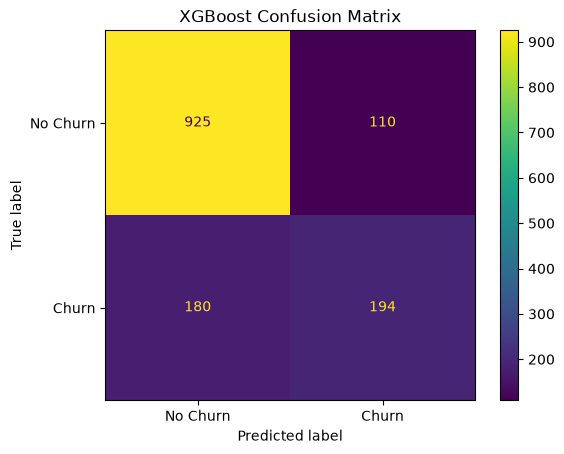

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [18]:
models_predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, predictions in models_predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, predictions))


Logistic Regression
[[933 102]
 [182 192]]

Random Forest
[[841 194]
 [144 230]]

XGBoost
[[925 110]
 [180 194]]


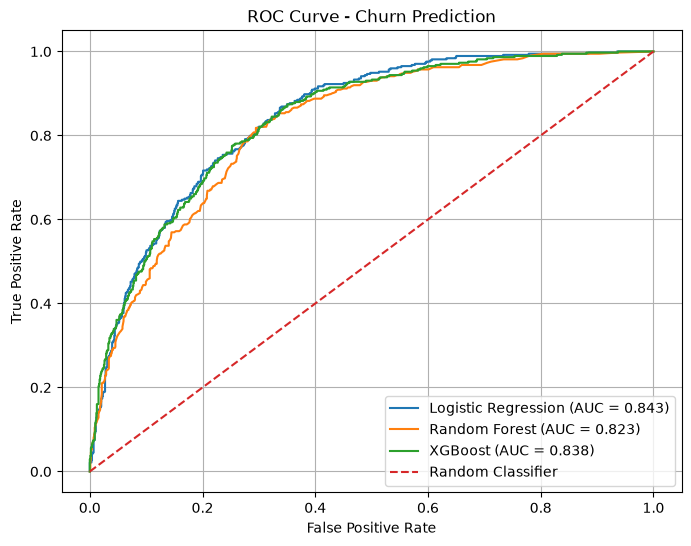

In [19]:
from sklearn.metrics import roc_curve, auc

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# AUC
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend()
plt.grid()
plt.show()

In [20]:
feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.097080
4,num__AvgMonthlySpend,0.091176
2,num__MonthlyCharges,0.090000
1,num__tenure,0.083444
9,num__IsMonthToMonth,0.051149
44,cat__Contract_Month-to-month,0.046933
35,cat__TechSupport_No,0.026568
26,cat__OnlineSecurity_No,0.026367
24,cat__InternetService_Fiber optic,0.026266
46,cat__Contract_Two year,0.024402


In [21]:
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
44,cat__Contract_Month-to-month,0.367762
9,num__IsMonthToMonth,0.185280
24,cat__InternetService_Fiber optic,0.092429
7,num__IsNewCustomer,0.041776
26,cat__OnlineSecurity_No,0.025379
46,cat__Contract_Two year,0.014545
53,cat__TenureGroup_0-12 Months,0.014150
23,cat__InternetService_DSL,0.013131
35,cat__TechSupport_No,0.012482
43,cat__StreamingMovies_Yes,0.009876


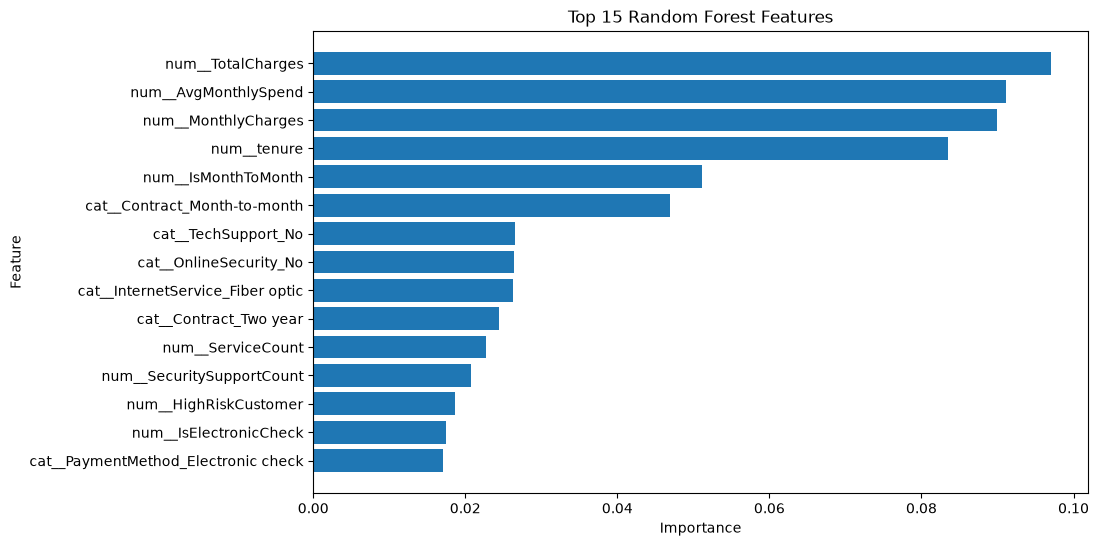

In [22]:
top_rf = rf_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.show()

In [23]:
logistic_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["AbsoluteCoefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = logistic_coefficients.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

logistic_coefficients.head(15)

,Feature,Coefficient,AbsoluteCoefficient
1,num__tenure,-1.107752,1.107752
23,cat__InternetService_DSL,-0.689528,0.689528
24,cat__InternetService_Fiber optic,0.685170,0.685170
2,num__MonthlyCharges,-0.567669,0.567669
46,cat__Contract_Two year,-0.535596,0.535596
9,num__IsMonthToMonth,0.398317,0.398317
56,cat__TenureGroup_49-72 Months,0.398076,0.398076
11,num__HighRiskCustomer,0.387634,0.387634
54,cat__TenureGroup_13-24 Months,-0.334967,0.334967
47,cat__PaperlessBilling_No,-0.322033,0.322033


In [24]:
joblib.dump(
    logistic_model,
    "../models/churn_model.pkl"
)

print("Churn model saved successfully!")

Churn model saved successfully!
